In [607]:
#!pip install numpy scikit-learn matplotlib

In [608]:
import numpy as np
import sklearn
import matplotlib

from sklearn.datasets import load_digits

In [609]:
digits = load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [610]:
data = digits["data"]
images = digits["images"]
target = digits["target"]
target_names = digits["target_names"]

data[0].shape, images[0].shape, target[0], target_names[0]

((64,), (8, 8), np.int64(0), np.int64(0))

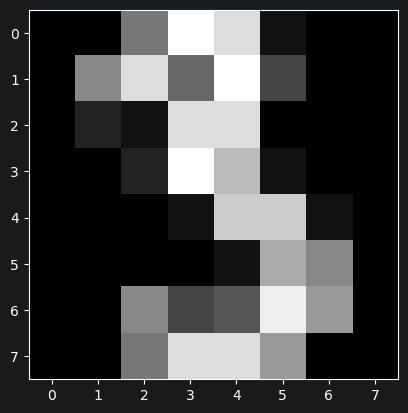

In [611]:
import numpy as np
import matplotlib . pyplot as plt
img = images[target == 3][0]
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

In [612]:
filte = (target % 3 == 0) * (target % 2 != 0)

filtered_data = data[filte]
filtered_target = target[filte]

filtered_target[filtered_target==3] = -1
filtered_target[filtered_target==9] = 1

filtered_target

array([-1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,
        1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,
       -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1,
       -1, -1,  1, -1, -1,  1,  1,  1,  1, -1, -1,  1, -1,  1, -1,  1,  1,
        1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,  1,
        1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,
        1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1,
        1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1,
        1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1, -1,  1, -1,  1, -1,
        1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1, -1, -1,
        1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1,
       -1,  1,  1, -1, -1

In [613]:
from sklearn import model_selection

X_all = filtered_data #/ 255
y_all = filtered_target

X_train, X_test, y_train, y_test =\
    model_selection.train_test_split(X_all, y_all,
        test_size = 0.4 , random_state = 0)

(8, 8)


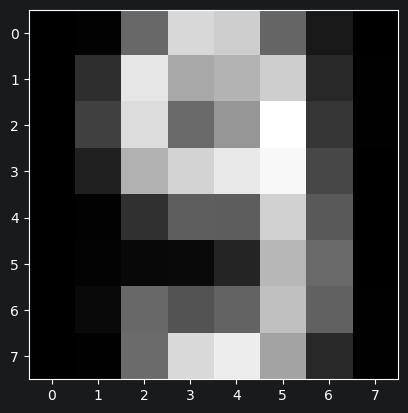

In [614]:
img = X_train[y_train == 1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


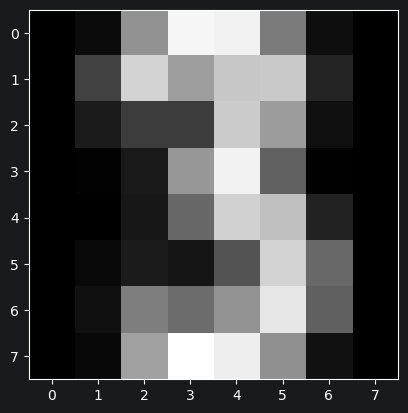

In [615]:
import numpy as np
import matplotlib . pyplot as plt
img = X_train[y_train == -1].mean(axis=0).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

(8, 8)


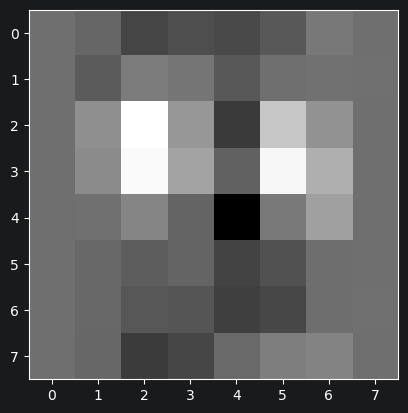

In [616]:
import numpy as np
import matplotlib . pyplot as plt
img = (X_train[y_train == 1].mean(axis=0) - X_train[y_train == -1].mean(axis=0)).reshape((8,8))
print(img.shape)
assert 2 == len(img.shape)
plt.figure()
plt.gray()
plt.imshow(img, interpolation = "nearest") # also try interpolation = "bicubic"
plt.show()

In [617]:
def handcrafted_conv(x):
    
    conv_matrix = np.array([[0,0,0,0], [0,0,0,0], [0.5, -1, 1, -0.5], [0.5, -1, 1, -0.5]])
    
    
    print((x * conv_matrix).shape)
    
    val = (x[:] * conv_matrix).sum(axis=2).sum(axis=1)
    
    return val


def features2d(x: np.array):
    
    f_1 = 0
    
    f_1 = x[:, 2*8+2] + x[:, 3*8+2] - 15# * 2 #- x[:, 2*8+1] * 2
    #for i in range(1):
     #   sub_matrix = np.array([x[:, 4*i:4*i+4], x[:, 4*i+8:4*i+12], x[:, 4*i+16:4*i+20], x[:, 4*i+24:4*i+28]]).reshape((x.shape[0], 4, 4))
      #  f_1 += handcrafted_conv(sub_matrix)
    
    #print(f_1)
    
    f_2 = 0
    #for i in range(2):
     #   sub_matrix = np.array([x[:, 4*i+32:4*i+4+32], x[:, 4*i+8+32:4*i+12+32], x[:, 4*i+16+32:4*i+20+32], x[:, 4*i+24+32:4*i+28+32]]).reshape((x.shape[0], 4, 4))
      #  f_2 += handcrafted_conv(sub_matrix)
    
    #f_2 = (x[:, 3*8+2]*3 - x[:, 3*8+3] - x[:, 7*8+2] ** 4 / 1000 - x[:, 7*8+1] ** 4 / 1000 + x[:, 3*8+5] ** 3 / 8 + x[:, 3*8+6] * 100 - x[:, 2*8+6] * 100) / 20
    #f_2 = (-x[:, 7*8+2] ** 10  + x[:, 3*8+5] ** 10) / 100000000000 +( x[:, 3*8+7] ** 4 - x[:, 7*8+1] ** 4) / 10000
    
    f_2 = x[:, 2*8+5] *0.5 + x[:, 3*8+5] - 15
    
    #print(f_2)
    
        
    return f_1, f_2

In [618]:

def features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2 

    f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5 

        
    return f_1, f_2

In [619]:
X_train[:4]

array([[ 0.,  0.,  0.,  1., 12., 16., 14.,  0.,  0.,  0.,  3., 14., 13.,
        15., 13.,  0.,  0.,  4., 16., 15., 13., 16.,  4.,  0.,  0.,  3.,
        16., 16., 16., 16.,  3.,  0.,  0.,  0.,  7.,  7., 14., 14.,  0.,
         0.,  0.,  0.,  0.,  0., 12., 11.,  0.,  0.,  0.,  0.,  0.,  0.,
        13., 10.,  0.,  0.,  0.,  0.,  0.,  0., 13., 12.,  0.,  0.],
       [ 0.,  0.,  9., 16., 14.,  6.,  0.,  0.,  0.,  6., 16.,  5., 10.,
        16.,  0.,  0.,  0.,  2., 15.,  7., 10., 16.,  3.,  0.,  0.,  0.,
         4.,  8., 12., 16.,  4.,  0.,  0.,  0.,  0.,  0.,  0., 16.,  7.,
         0.,  0.,  0.,  0.,  0.,  1., 16.,  8.,  0.,  0.,  0.,  3.,  0.,
         8., 16.,  1.,  0.,  0.,  0., 10., 16., 13.,  4.,  0.,  0.],
       [ 0.,  0.,  8., 14., 12.,  3.,  0.,  0.,  0.,  6., 16.,  6., 14.,
        14.,  0.,  0.,  0.,  6., 13.,  0.,  8., 14.,  0.,  0.,  0.,  2.,
        14., 14., 14., 16.,  3.,  0.,  0.,  0.,  2.,  4.,  6., 16.,  5.,
         0.,  0.,  0.,  0.,  0.,  0., 16.,  5.,  0.,  0.,  

In [620]:
x = X_train

print(x.shape)


features = features2d(x)

(217, 64)


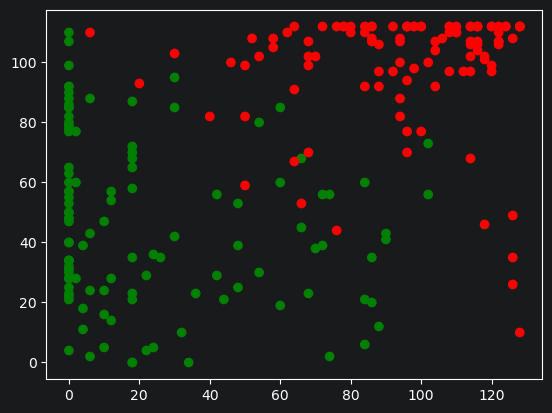

In [621]:
#print(features)

features = features2d(x)

color_dict = {-1: "green", 1: "red"} # Where green is 3s and red is 9s
colors = [color_dict[y] for y in y_train]

matplotlib.pyplot.scatter(features[0], features[1], c=colors)

In [622]:

def nearest_mean(training_features, training_labels, test_features):
    
    predicted_labels = 0
    
    x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
    x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()
            
    #predicted_labels = np.array([1 if abs(x_9_mean**2 + y_9_mean**2 - test_features[0][i]**2 - test_features[1][i]**2) < abs(x_3_mean**2 + y_3_mean**2 - test_features[0][i]**2 - test_features[1][i]**2) else -1 for i in range(len(test_features[0]))])
    predicted_labels = np.array([1 if abs((x_9_mean - test_features[0][i])**2 + (y_9_mean - test_features[1][i])**2) < (x_3_mean - test_features[0][i])**2 + (y_3_mean - test_features[1][i])**2 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

def descision_function(training_features, training_labels, test_features):
    
    predicted_labels = 0
    
    x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
    x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()
    
    beta1 = 1/210
    beta2 = 1/220
    b1 = -0.5
    b2 = -0.5
            
    predicted_labels = np.array([1 if (test_features[0][i]*beta1 + b1) + (test_features[1][i]*beta2 + b2) > 0 else -1 for i in range(len(test_features[0]))])
    
    return predicted_labels

In [623]:
training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1


predicted_labels = nearest_mean(training_features, training_labels, test_features)

In [624]:
predicted_labels

array([ 1,  1,  1, -1, -1,  1,  1,  1, -1, -1, -1, -1,  1, -1,  1, -1,  1,
        1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1, -1,  1,  1,  1, -1,
        1,  1,  1,  1, -1, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,
       -1,  1, -1, -1,  1, -1,  1, -1, -1, -1,  1, -1, -1,  1,  1,  1,  1,
       -1,  1, -1,  1, -1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1, -1, -1,
       -1, -1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,
        1,  1,  1, -1, -1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1, -1,  1, -1, -1, -1,  1,  1])

In [625]:
#F P +#F N
#    N

def calculate_errors(predicted_labels, true_labels):
    tp = sum(predicted_labels[true_labels==1]==true_labels[true_labels==1])
    tn = sum(predicted_labels[true_labels==-1]==true_labels[true_labels==-1])
    
    
    fp = sum(predicted_labels[predicted_labels==1]!=true_labels[predicted_labels==1])
    fn = sum(predicted_labels[predicted_labels==-1]!=true_labels[predicted_labels==-1])
    
    N = predicted_labels.shape[0]
        
    return tp, tn, fp, fn, N, (fp+fn)/N, (tp+tn)/N
    

In [626]:
true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)

In [627]:
errors

(np.int64(70),
 np.int64(65),
 np.int64(7),
 np.int64(4),
 146,
 np.float64(0.07534246575342465),
 np.float64(0.9246575342465754))

In [628]:


def features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 4 + x[:, 3*8+2] * 8#- 15# * 2 #- x[:, 2*8+1] * 2

    f_2 = x[:, 2*8+5] * 5 + x[:, 3*8+5] * 9#- 15

        
    return f_1, f_2


training_features = features2d(X_train)
test_features = features2d(X_test)

training_labels = y_train
training_labels[training_labels==3] = -1
training_labels[training_labels==9] = 1


predicted_labels = nearest_mean(training_features, training_labels, test_features)
predicted_labels2 = descision_function(training_features, training_labels, test_features)

true_labels = y_test
true_labels[true_labels==3] = -1
true_labels[true_labels==9] = 1

errors = calculate_errors(predicted_labels, true_labels)
errors2 = calculate_errors(predicted_labels2, true_labels)

errors[-1], errors[-2], errors2[-1], errors2[-2]

(np.float64(0.9794520547945206),
 np.float64(0.02054794520547945),
 np.float64(0.9794520547945206),
 np.float64(0.02054794520547945))

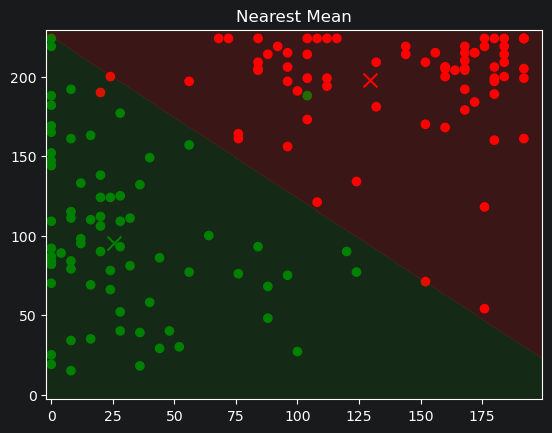

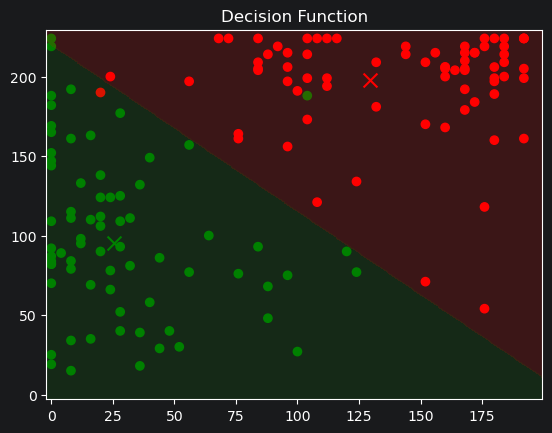

In [629]:
import matplotlib.pyplot as plt
import numpy as np


#fig, ax = plt.subplots()


color_dict = {-1: "green", 1: "red"}
colors = [color_dict[y] for y in true_labels]

#ax.scatter(test_features[0], test_features[1], c=colors)

x_9_mean, y_9_mean = training_features[0][training_labels==1].mean(), training_features[1][training_labels==1].mean()
x_3_mean, y_3_mean = training_features[0][training_labels==-1].mean(), training_features[1][training_labels==-1].mean()

xx, yy = np.meshgrid(np.arange(-2, 200, 0.5), np.arange(-3, 230, 0.5))
grid = (xx.ravel(), yy.ravel())

for func, name in [(nearest_mean, "Nearest Mean"), (descision_function, "Decision Function")]:
    fig, ax = plt.subplots()
    colors = [color_dict[y] for y in true_labels]
    ax.scatter(test_features[0], test_features[1], c=colors)
    ax.scatter(x_9_mean, y_9_mean, c="red", marker="x", s=100)
    ax.scatter(x_3_mean, y_3_mean, c="green", marker="x", s=100)

    Z = func(training_features, training_labels, grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["green", "red"], alpha=0.15)
    ax.set_title(name)
    plt.show()


# LDA

In [630]:
variance = np.var(X_train, axis=0)
mask = variance > 0.001
X_train_filtered = X_train[:, mask]
X_test_filtered = X_test[:, mask]

def fit_lda(training_features, training_labels):

    if isinstance(training_features, tuple) or isinstance(training_features, list):
        training_features = np.array(training_features).T
    training_features = np.asarray(training_features)
    training_labels = np.asarray(training_labels)

    # Compute class means
    mu_minus1 = training_features[training_labels == -1].mean(axis=0)
    mu_1 = training_features[training_labels == 1].mean(axis=0)

    # Compute class covariances
    X_minus1 = training_features[training_labels == -1]
    X_minus1_centered = X_minus1 - mu_minus1
    X_1 = training_features[training_labels == 1]
    X_1_centered = X_1 - mu_1

    cov_minus1 = X_minus1_centered.T @ X_minus1_centered
    cov_1 = X_1_centered.T @ X_1_centered
    covmat = (cov_minus1 + cov_1) / training_features.shape[0]

    mu = np.vstack([mu_minus1, mu_1])

    # priors
    N = training_features.shape[0]
    N_minus1 = (training_labels == -1).sum()
    N_1 = (training_labels == 1).sum()
    p = np.array([N_minus1 / N, N_1 / N])

    return mu, covmat, p


In [631]:
mu, covmat, p = fit_lda(training_features, training_labels)

def predict_lda(mu, covmat, p, test_features):
    """Predict labels using LDA parameters. Returns array of {-1,1}."""
    # support tuple input (features2d) or numpy array
    if isinstance(test_features, tuple):
        X = np.array(test_features).T
    else:
        X = np.array(test_features)

    inv_covmat = np.linalg.inv(covmat)
    mu_minus1 = mu[0]
    mu_1 = mu[1]

    beta = inv_covmat @ (mu_1 - mu_minus1)
    b = -0.5 * (mu_1 + mu_minus1) @ beta + np.log(p[1] / p[0])

    scores = X @ beta + b
    predicted_labels = np.where(scores > 0, 1, -1)
    return predicted_labels


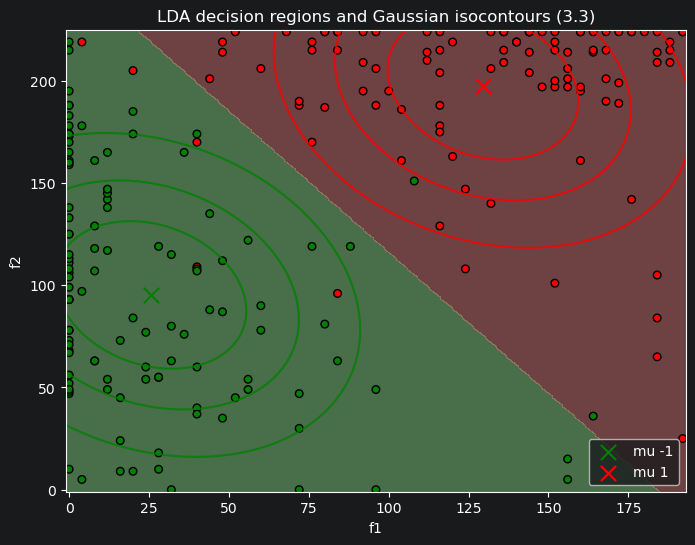

In [632]:
# LDA visualization: decision regions + Gaussian isocontours (Aufgabe 3.3)
import matplotlib.pyplot as plt
from matplotlib import cm

# prepare 2D features and labels
train_f2 = features2d(X_train)
Xf2_train = np.array(train_f2).T
Xf2_test = np.array(features2d(X_test)).T
y_train_m = y_train.copy(); y_train_m[y_train_m==3] = -1; y_train_m[y_train_m==9] = 1
y_test_m  = y_test.copy();  y_test_m[y_test_m==3]   = -1; y_test_m[y_test_m==9]   = 1

# fit LDA on the 2D features
mu2, cov2, p2 = fit_lda(Xf2_train, y_train_m)

# grid for plotting decision regions
pad = 1.0
x_min, x_max = Xf2_train[:,0].min() - pad, Xf2_train[:,0].max() + pad
y_min, y_max = Xf2_train[:,1].min() - pad, Xf2_train[:,1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# predict grid labels with our LDA
Z = predict_lda(mu2, cov2, p2, grid).reshape(xx.shape)

# plot decision regions
fig, ax = plt.subplots(figsize=(8,6))
ax.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=["lightgreen", "lightcoral"], alpha=0.4)

# plot training points
colors = ["green" if y == -1 else "red" for y in y_train_m]
ax.scatter(Xf2_train[:,0], Xf2_train[:,1], c=colors, edgecolor='k', s=30)
ax.scatter(mu2[0][0], mu2[0][1], c='green', marker='x', s=120, label='mu -1')
ax.scatter(mu2[1][0], mu2[1][1], c='red',   marker='x', s=120, label='mu 1')

# overlay Gaussian isocontours using the pooled covariance (cov2)
# handle potential singularity
try:
    inv_cov2 = np.linalg.inv(cov2)
    det_cov2 = np.linalg.det(cov2)
except Exception:
    inv_cov2 = np.linalg.pinv(cov2)
    det_cov2 = max(np.linalg.det(cov2), 1e-12)

norm_const = 1.0 / (2 * np.pi * np.sqrt(max(det_cov2, 1e-12)))
for mu_c, col in [(mu2[0], 'green'), (mu2[1], 'red')]:
    diffs = grid - mu_c
    exponents = -0.5 * np.einsum('ij,ij->i', diffs @ inv_cov2, diffs)
    pdf = norm_const * np.exp(exponents)
    pdf2 = pdf.reshape(xx.shape)
    levels = np.linspace(pdf2.min(), pdf2.max(), 5)[1:]
    ax.contour(xx, yy, pdf2, levels=levels, colors=col, alpha=0.8)

ax.set_xlabel('f1')
ax.set_ylabel('f2')
ax.set_title('LDA decision regions and Gaussian isocontours (3.3)')
ax.legend()
plt.show()


In [633]:
# Aufgabe 3.4: 10-fold CV + sklearn comparison (2D features)
from sklearn.model_selection import KFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SklearnLDA

# Prepare 2D data
train_f2 = features2d(X_train)
Xf2_full = np.array(train_f2).T  # Shape (N, 2)
y_full = y_train.copy()
y_full[y_full == 3] = -1
y_full[y_full == 9] = 1

print("=" * 60)
print("Aufgabe 3.4: 10-fold Cross-Validation und sklearn-Vergleich")
print("=" * 60)

# 10-fold CV for our LDA implementation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
our_cv_errors = []
sklearn_cv_errors = []

for fold_idx, (train_idx, test_idx) in enumerate(kfold.split(Xf2_full)):
    X_train_fold = Xf2_full[train_idx]
    y_train_fold = y_full[train_idx]
    X_test_fold = Xf2_full[test_idx]
    y_test_fold = y_full[test_idx]
    
    # Our implementation
    mu_fold, cov_fold, p_fold = fit_lda(X_train_fold, y_train_fold)
    preds_our = predict_lda(mu_fold, cov_fold, p_fold, X_test_fold)
    error_our = (preds_our != y_test_fold).mean()
    our_cv_errors.append(error_our)
    
    # sklearn LDA (uses label {-1, 1} natively)
    lda_sklearn = SklearnLDA()
    lda_sklearn.fit(X_train_fold, y_train_fold)
    preds_sklearn = lda_sklearn.predict(X_test_fold)
    error_sklearn = (preds_sklearn != y_test_fold).mean()
    sklearn_cv_errors.append(error_sklearn)
    
    print(f"Fold {fold_idx+1:2d}: Our LDA error={error_our:.4f}, sklearn error={error_sklearn:.4f}")

print("\n" + "=" * 60)
print(f"Our LDA:    Mean CV error = {np.mean(our_cv_errors):.4f} ± {np.std(our_cv_errors):.4f}")
print(f"sklearn LDA: Mean CV error = {np.mean(sklearn_cv_errors):.4f} ± {np.std(sklearn_cv_errors):.4f}")
print("=" * 60)

# Test on full train/test split
mu_full, cov_full, p_full = fit_lda(Xf2_full, y_full)
Xf2_test = np.array(features2d(X_test)).T
y_test_m = y_test.copy()
y_test_m[y_test_m == 3] = -1
y_test_m[y_test_m == 9] = 1

preds_our_full = predict_lda(mu_full, cov_full, p_full, Xf2_full)
preds_our_test = predict_lda(mu_full, cov_full, p_full, Xf2_test)
train_error_our = (preds_our_full != y_full).mean()
test_error_our = (preds_our_test != y_test_m).mean()

lda_sklearn_full = SklearnLDA()
lda_sklearn_full.fit(Xf2_full, y_full)
preds_sklearn_full = lda_sklearn_full.predict(Xf2_full)
preds_sklearn_test = lda_sklearn_full.predict(Xf2_test)
train_error_sklearn = (preds_sklearn_full != y_full).mean()
test_error_sklearn = (preds_sklearn_test != y_test_m).mean()

print("\nTrain/Test Split Results (2D features):")
print(f"Our LDA:     Train error={train_error_our:.4f}, Test error={test_error_our:.4f}")
print(f"sklearn LDA: Train error={train_error_sklearn:.4f}, Test error={test_error_sklearn:.4f}")
print("=" * 60)


Aufgabe 3.4: 10-fold Cross-Validation und sklearn-Vergleich
Fold  1: Our LDA error=0.0455, sklearn error=0.0455
Fold  2: Our LDA error=0.0455, sklearn error=0.0455
Fold  3: Our LDA error=0.0000, sklearn error=0.0000
Fold  4: Our LDA error=0.0455, sklearn error=0.0455
Fold  5: Our LDA error=0.0000, sklearn error=0.0000
Fold  6: Our LDA error=0.0000, sklearn error=0.0000
Fold  7: Our LDA error=0.0455, sklearn error=0.0455
Fold  8: Our LDA error=0.0952, sklearn error=0.0952
Fold  9: Our LDA error=0.0000, sklearn error=0.0000
Fold 10: Our LDA error=0.0476, sklearn error=0.0476

Our LDA:    Mean CV error = 0.0325 ± 0.0301
sklearn LDA: Mean CV error = 0.0325 ± 0.0301

Train/Test Split Results (2D features):
Our LDA:     Train error=0.0323, Test error=0.0274
sklearn LDA: Train error=0.0323, Test error=0.0274


# SVM

In [634]:
# For Graphing Later
losses = []
training_errors = []

def fit_svm(training_features, training_labels):
    if type(training_features) == tuple:
        training_features = np.array(training_features).reshape(training_labels.shape[0], -1)
        
    
    n = training_features.shape[0]

    beta = np.random.normal(size=(training_features.shape[1]))
    b = 0#np.random.normal(size=(training_features.shape[1]))
    
    lamb = 1
    tau = .1
    
    #print(training_labels.shape, training_features.shape, beta.shape)
    
    #print((training_labels * (training_features @ beta + b)).shape)
    
    loss_old = 100000
    count = 0
    
    for x in range(10000):
        mask = (1 - training_labels * (training_features @ beta + b)) > 0


        beta = beta - tau * lamb/n * (-training_labels[mask] @ training_features[mask]).sum()
        b = b - tau * lamb/n * (-training_labels[mask]).sum()
        
        loss = 1/2 * beta @ beta.T + lamb/n * (np.maximum(0, 1 - training_labels * (training_features @ beta + b))).sum()
        losses.append(loss) # Need to visualize the Loss

        predicted = predict_svm(training_features, beta, b)
        iteration_error = calculate_errors(predicted, training_labels)[5]
        training_errors.append(iteration_error) # Need to visualize the training error
        
        if loss >= loss_old and count >= 10:
            count = 0
            tau *= 0.5
        elif loss >= loss_old and count < 10:
            count += 1
        else:
            loss_old = loss
         
        #tau *= 0.999
    
    #print(1- training_labels * (training_features @ beta + b))
        
    print(loss)
    
    

    return beta, b


def predict_svm(test_features, beta, b):
    
    if type(test_features) == tuple:
        test_features = np.array(test_features).T
    
    
    #print(test_features)
    
    predicted_labels = test_features @ beta + b
    
    #print(predicted_labels)
    
    predicted_labels = predicted_labels * -1
    
    predicted_labels[predicted_labels > 0] = 1
    predicted_labels[predicted_labels < 0] = -1
    
    return predicted_labels

In [635]:
def search_lambda(training_features, training_labels):
    
    if type(training_features) == tuple:        
        training_features = np.array(training_features).T

    split = training_features.shape[0] // 5
    validation_features, validation_labels = training_features[:split], training_labels[:split]
    training_features, training_labels   = training_features[split:], training_labels[split:]

    n = training_features.shape[0]
    
    beta0 = np.random.normal(size=(training_features.shape[1]))
    b = 0#np.random.normal(size=(training_features.shape[1]))
    
    lambs = np.logspace(-4, 2, num=7)
    print(lambs)
    tau = 1
    
    best_lambda = 1
    best_beta = None
    best_b = None
    best_loss = 100000

    b_losses = []
    b_errors = []
    
    for lamb in lambs:
        t_loss = []
        t_error = []

        loss_old = 100000
        count = 0
        beta = beta0.copy()
        b = 0
        tau = 1
        
        for x in range(10000):
            mask = (1 - training_labels * (training_features @ beta + b)) > 0
            grad_beta = beta + lamb/n * (-training_labels[mask, np.newaxis] * training_features[mask]).sum(axis=0)
            beta = beta - tau * grad_beta
            grad_b = lamb/n * (-training_labels[mask]).sum()
            b = b - tau * grad_b

            loss = 1/2 * beta @ beta.T + lamb/n * (np.maximum(0, 1 - training_labels * (training_features @ beta + b))).sum()
            t_loss.append(loss)

            iteration_error = calculate_errors(predict_svm(training_features, beta, b), training_labels)[5]
            t_error.append(iteration_error) # Need to visualize the training error

            if loss >= loss_old and count >= 10:
               count = 0
               tau /= 10
            elif loss >= loss_old and count < 10:
               count += 1
            else:
               loss_old = loss

            # tau *= 0.99
        
        valid_loss = 1/2 * beta @ beta.T + 1/n * (np.maximum(0, 1 - validation_labels * (validation_features @ beta + b))).sum()
        
        predicted_labels = predict_svm(validation_features, beta, b)
        
        #print(predicted_labels)
        
        errors = calculate_errors(predicted_labels, validation_labels)
        
        print(f"lambda: {lamb}, training loss: {loss:.4f}, validation loss: {valid_loss:.4f}, valid acc: {errors[5]:.4f}, valid error: {errors[6]:.4f}, best loss:{best_loss:.4f}")



        if valid_loss < best_loss:
            b_losses = t_loss
            b_errors = t_error
            best_loss = valid_loss
            best_lambda = lamb.copy()
            best_beta = beta.copy()
            best_b = b.copy()
    

    print(best_lambda)
    
    return best_lambda, best_beta, best_b, b_losses, b_errors

best_lambda = search_lambda(X_train, y_train)
best_lambda



[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation loss: 0.2455, valid acc: 0.4651, valid error: 0.5349, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2241, valid acc: 0.4884, valid error: 0.5116, best loss:0.2455
lambda: 0.01, training loss: 0.0056, validation loss: 0.0940, valid acc: 1.0000, valid error: 0.0000, best loss:0.2241
lambda: 0.1, training loss: 0.0708, validation loss: 0.0737, valid acc: 0.9767, valid error: 0.0233, best loss:0.0940
lambda: 1.0, training loss: 5.3007, validation loss: 4.9773, valid acc: 0.9535, valid error: 0.0465, best loss:0.0737
lambda: 10.0, training loss: 551.3363, validation loss: 504.0695, valid acc: 0.9535, valid error: 0.0465, best loss:0.0737
lambda: 100.0, training loss: 7189.4491, validation loss: 6555.4601, valid acc: 0.9767, valid error: 0.0233, best loss:0.0737
0.1


(np.float64(0.1),
 array([ 0.00000000e+00, -7.60964149e-03, -3.81916055e-02, -3.31087136e-02,
        -4.13254187e-02, -3.39183079e-02,  3.78360665e-03,  3.74016148e-04,
         0.00000000e+00, -1.43666328e-02,  6.58355321e-03,  2.70007800e-03,
        -1.90257265e-02, -2.01283264e-03, -3.34765668e-03,  1.32620852e-03,
         0.00000000e+00,  3.64696454e-02,  1.43335221e-01,  4.88752781e-02,
        -5.29417606e-02,  9.02792530e-02,  3.39155015e-02,  1.12405354e-03,
         0.00000000e+00,  3.43846790e-02,  1.48952105e-01,  5.83200727e-02,
        -1.57652648e-02,  1.35032819e-01,  7.00162061e-02,  0.00000000e+00,
         0.00000000e+00,  2.15246040e-03,  2.58810059e-02, -1.02838462e-02,
        -1.20220332e-01, -8.52765386e-06,  5.05526470e-02,  0.00000000e+00,
         0.00000000e+00, -6.78998804e-03, -2.12065582e-02, -1.22562190e-02,
        -4.20879752e-02, -4.18021200e-02, -2.43515506e-03,  0.00000000e+00,
         0.00000000e+00, -7.54740806e-03, -2.45578106e-02, -2.67072863

In [636]:
def for_svm_features2d(x: np.array):
    

    f_1 = x[:, 2*8+2] * 6 + x[:, 3*8+2] * 2 

    f_2 = x[:, 2*8+5] * 2 + x[:, 3*8+5] * 5 

        
    return f_1, f_2

In [637]:
_, beta, b, t_loss, t_error = search_lambda(X_train, y_train)

_, beta_2, b_2, _, _ = search_lambda(for_svm_features2d(X_train), y_train)
beta, b, beta_2, b_2

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, validation loss: 0.2455, valid acc: 0.4651, valid error: 0.5349, best loss:100000.0000
lambda: 0.001, training loss: 0.0009, validation loss: 0.2241, valid acc: 0.4884, valid error: 0.5116, best loss:0.2455
lambda: 0.01, training loss: 0.0056, validation loss: 0.1000, valid acc: 0.9767, valid error: 0.0233, best loss:0.2241
lambda: 0.1, training loss: 0.0784, validation loss: 0.0811, valid acc: 0.9767, valid error: 0.0233, best loss:0.1000
lambda: 1.0, training loss: 5.0974, validation loss: 4.7928, valid acc: 0.9535, valid error: 0.0465, best loss:0.0811
lambda: 10.0, training loss: 522.0532, validation loss: 475.2524, valid acc: 0.9535, valid error: 0.0465, best loss:0.0811
lambda: 100.0, training loss: 8966.8283, validation loss: 8199.1939, valid acc: 1.0000, valid error: 0.0000, best loss:0.0811
0.1
[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
lambda: 0.0001, training loss: 0.0001, valid

(array([ 0.        , -0.00837333, -0.0424001 , -0.03617614, -0.04365579,
        -0.03503619,  0.00416019,  0.0003615 ,  0.        , -0.01513705,
         0.00787918,  0.00251164, -0.02222883, -0.00446948, -0.0032606 ,
         0.00129259,  0.        ,  0.03844708,  0.15113652,  0.04878051,
        -0.05793786,  0.09212425,  0.03505121,  0.00110797,  0.        ,
         0.0351678 ,  0.15364747,  0.06030345, -0.01716497,  0.14112021,
         0.0724008 ,  0.        ,  0.        ,  0.00219862,  0.02638303,
        -0.01166933, -0.12764348,  0.00082359,  0.0542763 ,  0.        ,
         0.        , -0.00641662, -0.02011295, -0.01300382, -0.0471703 ,
        -0.04534851,  0.00051763,  0.        ,  0.        , -0.00693017,
        -0.02261731, -0.02782057, -0.0603604 , -0.05585168,  0.00404096,
         0.00186613,  0.        , -0.00658169, -0.05447678, -0.04074762,
        -0.00664685,  0.01357523,  0.0256629 ,  0.00122361]),
 np.float64(0.0009118135376756075),
 array([0.05527205, 0.0733

In [638]:
beta, b = fit_svm(X_train, y_train)
beta_2, b_2 = fit_svm(training_features, y_train)
beta, b, beta_2, b_2

37.60354597008754
16.10033345512282


(array([-4.96720594e-01, -9.23131865e-01, -9.33409762e-01, -6.16642925e-01,
        -6.91097310e-02,  8.01509198e-02,  3.79378285e-01,  7.88280922e-01,
         2.59487177e-01,  1.37696518e+00, -7.14137483e-01,  1.50515383e+00,
         9.90432456e-01,  7.13140511e-01, -6.37604082e-01, -9.47921481e-01,
         7.13447362e-01, -2.16304513e-01,  6.91327885e-01, -2.79792343e-03,
         4.46958879e-01, -1.21870178e+00, -6.95911176e-01,  7.08572169e-01,
         1.15259098e-01,  2.21739415e+00,  4.84880422e-01, -1.81006848e+00,
         8.55207959e-01, -1.90449703e-01,  1.82499902e-01,  6.92500334e-01,
         1.36039884e+00, -6.16096954e-01, -5.83751829e-01, -3.72474346e-01,
         1.96908418e-03,  1.05174525e+00,  1.97020342e+00,  1.18032752e+00,
        -8.47140219e-01, -1.44938754e+00,  4.72267476e-01, -2.37421448e-01,
        -3.46169979e-01,  6.22862323e-01,  5.72635642e-01,  6.33448174e-01,
        -2.73834636e-01, -1.11695664e+00,  2.64999192e-01, -7.40924040e-03,
         8.4

In [639]:
predicted_labels_svm = predict_svm(X_test, beta, b)
predicted_labels_svm2 = predict_svm(for_svm_features2d(X_test), beta_2, b_2)

predicted_labels_svm, predicted_labels_svm2

(array([ 1.,  1., -1.,  1., -1., -1., -1., -1., -1., -1.,  1.,  1., -1.,
        -1., -1., -1., -1., -1., -1.,  1., -1., -1.,  1.,  1., -1.,  1.,
         1.,  1.,  1., -1.,  1., -1., -1., -1.,  1., -1.,  1., -1., -1.,
        -1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1.,
         1.,  1., -1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1., -1.,  1.,
         1., -1., -1.,  1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1.,
        -1.,  1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1.,
         1.,  1.,  1., -1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1.,  1.,
        -1.,  1.,  1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1., -1.,
         1., -1., -1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.,  1.,  1.,
        -1.,  1.,  1., -1., -1., -1.,  1., -1., -1.,  1., -1.,  1.,  1.,
         1.,  1.,  1.]),
 array([ 1.,  1.,  1., -1., -1., -1.,  1., -1.,  1., -1., -1.,  1.,  1.,
        -1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,
        -1.,  1., -1.,  1.

In [640]:
def calculate_errors(predicted_labels, true_labels):
    tp = sum(predicted_labels[true_labels==1]==true_labels[true_labels==1])
    tn = sum(predicted_labels[true_labels==-1]==true_labels[true_labels==-1])
    
    
    fp = sum(predicted_labels[predicted_labels==1]!=true_labels[predicted_labels==1])
    fn = sum(predicted_labels[predicted_labels==-1]!=true_labels[predicted_labels==-1])
    
    N = predicted_labels.shape[0]
        
    return tp, tn, fp, fn, N, (fp+fn)/N, (tp+tn)/N

errors_svm_1 = calculate_errors(predicted_labels_svm, true_labels)
errors_svm_2 = calculate_errors(predicted_labels_svm2, true_labels)

errors_svm_1, errors_svm_2

((np.int64(37),
  np.int64(32),
  np.int64(40),
  np.int64(37),
  146,
  np.float64(0.5273972602739726),
  np.float64(0.4726027397260274)),
 (np.int64(41),
  np.int64(55),
  np.int64(17),
  np.int64(33),
  146,
  np.float64(0.3424657534246575),
  np.float64(0.6575342465753424)))

# Plotting???

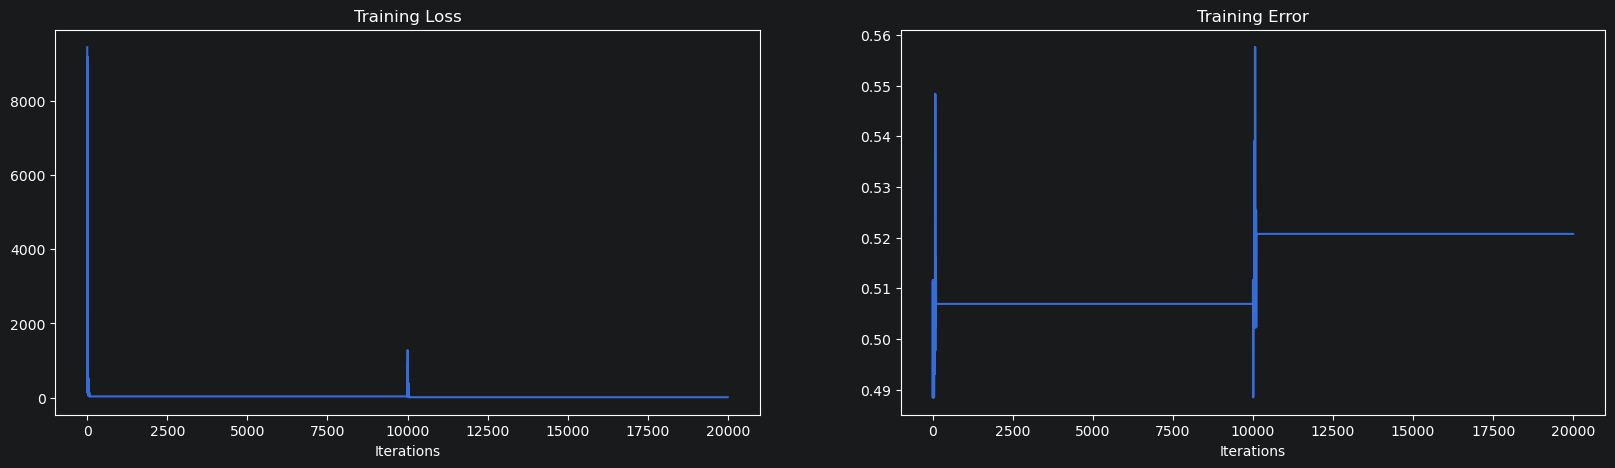

In [641]:
# Visualize in a diagram how the Loss and the training error change in the course of iteration.
# svm is called twice so this call needs to move or a blip is created in training loss because it continues to append
iterations = range(len(training_errors))

fig, axes = plt.subplots(1, 2, figsize=(20,5))

axes[0].set_xlabel("Iterations")
axes[0].set_title("Training Loss")
axes[0].plot(iterations, losses)

axes[1].set_xlabel("Iterations")
axes[1].set_title("Training Error")
axes[1].plot(iterations, training_errors)
plt.show()

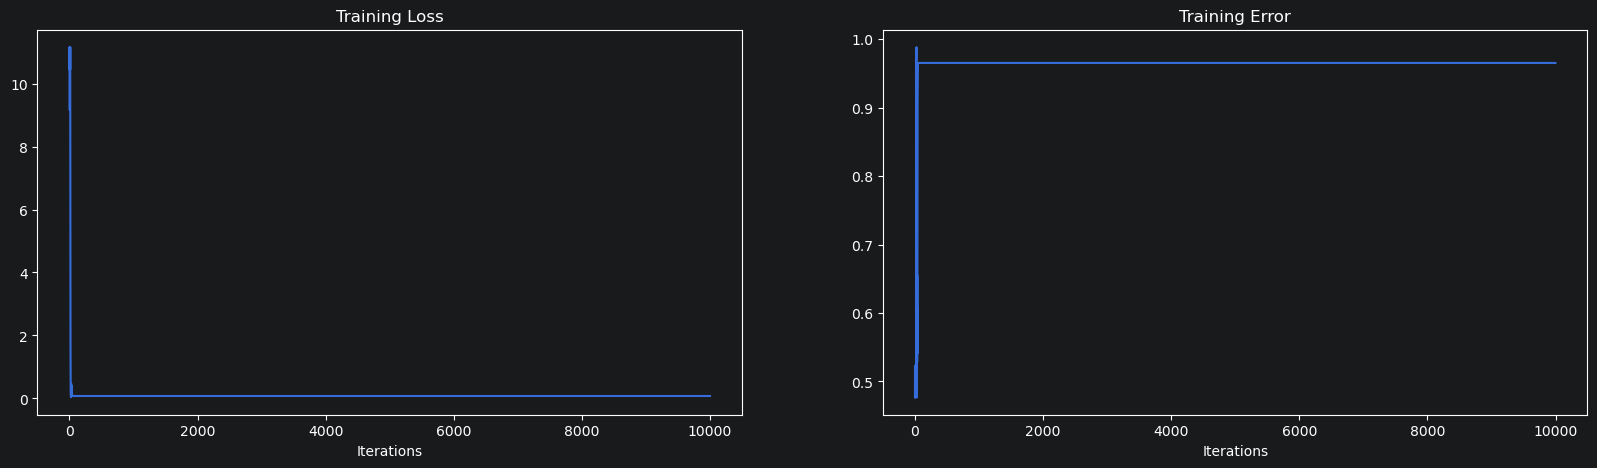

In [642]:
iterations = range(len(t_loss))

fig, axes = plt.subplots(1, 2, figsize=(20,5))

axes[0].set_xlabel("Iterations")
axes[0].set_title("Training Loss")
axes[0].plot(iterations, t_loss)

axes[1].set_xlabel("Iterations")
axes[1].set_title("Training Error")
axes[1].plot(iterations, t_error)
plt.show()